# 📌 Introduction & Overview

Dataset Overview: The mbti.csv dataset consists of both unstructured text and structured metadata, containing a total of 444 entries across 6 distinct columns: index, id, title, texts, labels, and forum. It aggregates online forum discussions and threads focused on Myers-Briggs Type Indicator (MBTI) personality analysis.

Data Integrity & Structure: The dataset features 2 integer columns (int64) and 4 text-based columns (object) with zero missing (null) values across all records, providing a clean and complete foundation for text processing and analytics.

## 1. Loading and exploring data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
mbti_data = pd.read_csv("/kaggle/input/datasets/mangkonesinnavong/mbti-dataset/mbti.csv.csv")
mbti_data.head()

,index,id,title,texts,labels,forum
0,0,7,What do INFJs look for in a relationship?,"[""I'm an INFJ, and so far I have not had any l...",['Dating & Relationships'],Dating & Relationships
1,1,9,What do you prefer?,"[""I'm a Sexual-Social. I never really used Ins...","['Sexual-Socials', 'Instincts']",Sexual-Socials
2,2,11,Secure-sexuals...unite!,['Who else is a secure-sexuals out there? Post...,"['Sexual-Secures', 'Instincts']",Sexual-Secures
3,3,12,Which type makes the best actor/performer?,['I used to do theatre...there are a bunch of ...,"['General Topics', 'Career & Education']",Career & Education
4,4,14,What makes you angry,"[""What pisses of ENFJs more than anything else...","['Romantics ', 'ENFJ - Teacher', 'Personality']",ENFJ - Teacher


In [3]:
mbti_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 444 entries, 0 to 443
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   index   444 non-null    int64 
 1   id      444 non-null    int64 
 2   title   444 non-null    object
 3   texts   444 non-null    object
 4   labels  444 non-null    object
 5   forum   444 non-null    object
dtypes: int64(2), object(4)
memory usage: 20.9+ KB


In [4]:
mbti_data.dtypes

index      int64
id         int64
title     object
texts     object
labels    object
forum     object
dtype: object

In [5]:
mbti_data.isnull().sum()

index     0
id        0
title     0
texts     0
labels    0
forum     0
dtype: int64

### EDA Row Data

### Top Popular Forums Analysis

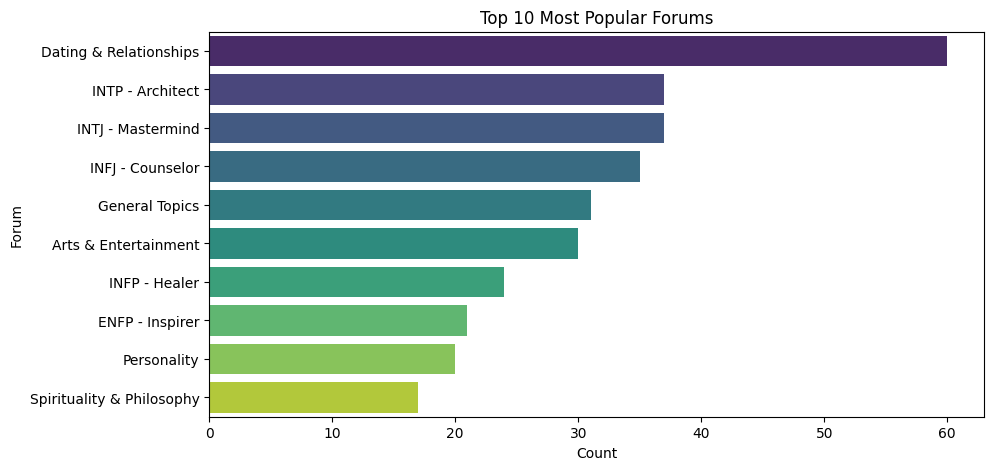

In [6]:
# Visualize the top 10 most popular forums

plt.figure(figsize=(10,5))
sns.countplot(
    y='forum',
    data=mbti_data,
    order=mbti_data['forum'].value_counts().index[:10],
    palette='viridis'
)

plt.title('Top 10 Most Popular Forums')
plt.xlabel('Count')
plt.ylabel('Forum')
plt.show()

### Extract and Analyze Frequent Labels

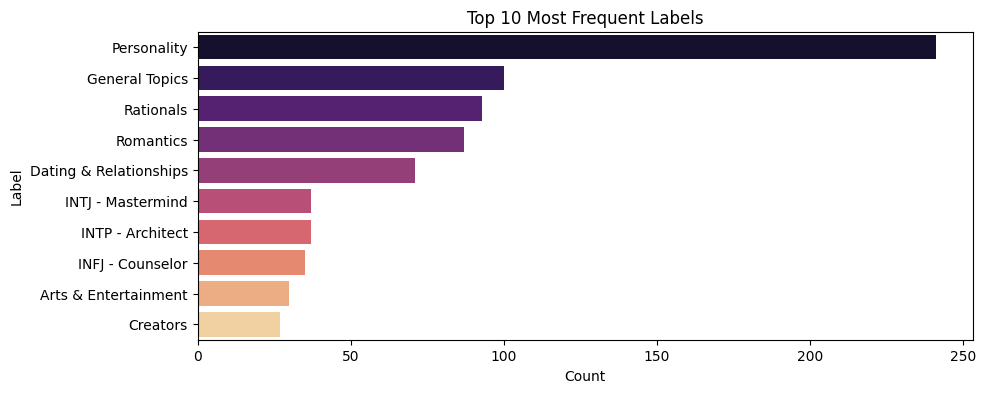

In [7]:
import ast
from collections import Counter

# Flatten and extract individual labels from string representations of lists
all_labels = []
for label_str in mbti_data['labels']:
    try:
        labels_list = ast.literal_eval(label_str)
        all_labels.extend([l.strip() for l in labels_list])
    except:
        pass

# Count label occurrences and build a summary DataFrame
label_counts = Counter(all_labels)
label_df = pd.DataFrame(
    label_counts.most_common(10), columns=['Label', 'Count']
)

# Plot the most frequent labels
plt.figure(figsize=(10, 4))
sns.barplot(x='Count', y='Label', data=label_df, palette='magma')
plt.title('Top 10 Most Frequent Labels')
plt.xlabel('Count')
plt.ylabel('Label')
plt.show()

### Title Word Count Distribution

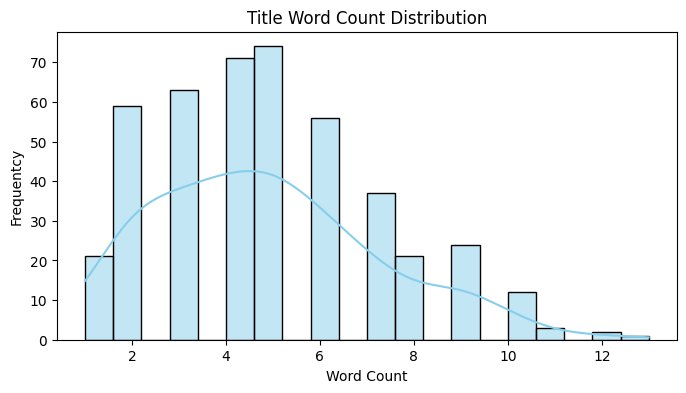

In [8]:
# Compute word count for titles

mbti_data['title_word_count'] = mbti_data['title'].apply(
    lambda x: len(str(x).split())
)

# Plot title word count distribution
plt.figure(figsize=(8,4))
sns.histplot(
    mbti_data['title_word_count'], kde=True, color='skyblue', bins=20
)

plt.title('Title Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequentcy')
plt.show()

### Text Content Word Count Distribution

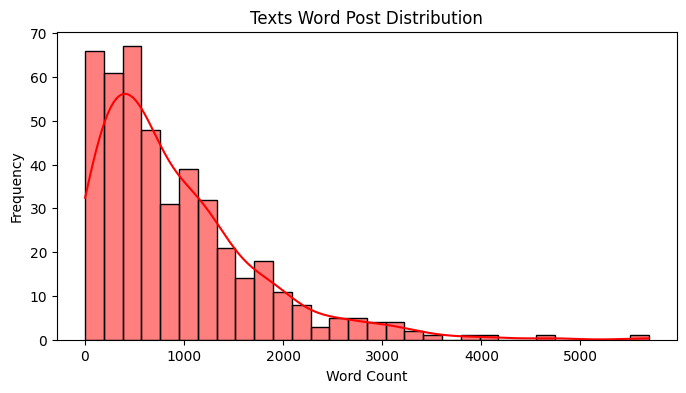

In [9]:
# Compute word count for post body texts
mbti_data['text_word_count'] = mbti_data['texts'].apply(
    lambda x: len(str(x).split())
)

# Plot post text word count distribution
plt.figure(figsize=(8,4))
sns.histplot(
    mbti_data['text_word_count'], kde=True, color='Red', bins=30
)

plt.title('Texts Word Post Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

### Mention Frequency of 16 MBTI Personality

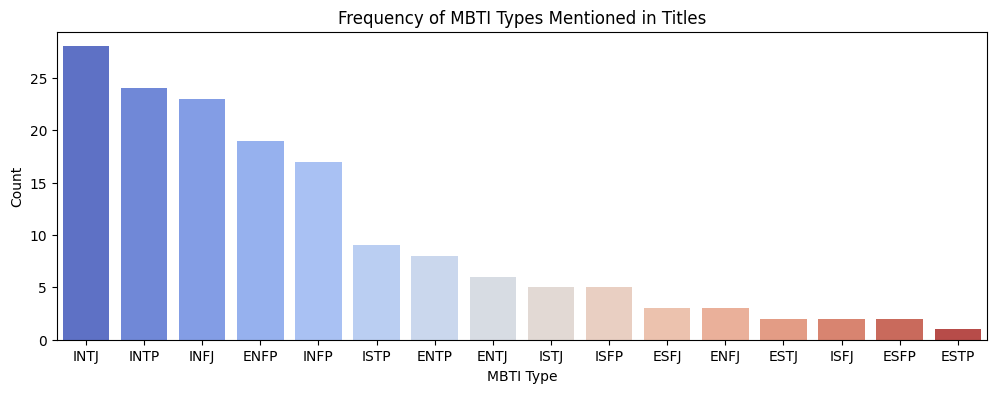

In [10]:
import re

# Define all 16 MBTI personality type

mbti_types = [
    'INTJ',
    'ENTJ',
    'INTP',
    'ENTP',
    'INFJ',
    'INFP',
    'ENFJ',
    'ENFP',
    'ISTJ',
    'ISFJ',
    'ESTJ',
    'ESFJ',
    'ISTP',
    'ISFP',
    'ESTP',
    'ESFP'
]

# Function to detect MBTI type mentions using word boundaries
def find_mbti(text):
    found = []
    for mbti in mbti_types:
        if re.search(r'\b' + mbti + r'\b', str(text), re.IGNORECASE):
            found.append(mbti.upper())
    return found

# Extract all MBTI mentions across titles
all_mentioned_mbti = []
mbti_data['title'].apply(lambda x: all_mentioned_mbti.extend(find_mbti(x)))

# Count frequencies and plot
mbti_mention_counts = Counter(all_mentioned_mbti)
mbti_df = pd.DataFrame(
    mbti_mention_counts.most_common(), columns=['MBTI_Type', 'Count']
)

plt.figure(figsize=(12, 4))
sns.barplot(x='MBTI_Type', y='Count', data=mbti_df, palette='coolwarm')
plt.title('Frequency of MBTI Types Mentioned in Titles')
plt.xlabel('MBTI Type')
plt.ylabel('Count')
plt.show()

### Data Duplication Check

In [11]:
# Check for duplicate titles and texts
duplicate_titles = mbti_data.duplicated(subset=['title']).sum()
duplicate_texts = mbti_data.duplicated(subset=['texts']).sum()

print(f'Number of duplicate titles: {duplicate_titles}')
print(f'Number of duplicate texts: {duplicate_texts}')

Number of duplicate titles: 11
Number of duplicate texts: 2


## 2. Data Preprocessing & Cleaning

In [12]:
import ast
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### 2.1 Remove Duplicate Rows

In [13]:
mbti_clean = mbti_data.drop_duplicates(subset=['texts']).copy()
mbti_clean = mbti_clean.drop_duplicates(subset=['title'])

### 2.2 Parse 'labels' column into actual Python lists

In [14]:
def parse_labels(label_str):
    try:
        return ast.literal_eval(label_str)
    except:
        return []

mbti_clean['clean_labels'] = mbti_clean['labels'].apply(parse_labels)

# Initailize Stopwrods and Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### 2.3 Text Cleaning Function

In [15]:
def clean_text_pipeline(text):
    if not isinstance(text, str):
        return ''

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize, remove stopwords, and lemmatize
    words = text.split()
    cleaned_words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(cleaned_words)


# Apply Cleaning to Title and Texts
mbti_clean['clean_title'] = mbti_clean['title'].apply(clean_text_pipeline)
mbti_clean['clean_texts'] = mbti_clean['texts'].apply(clean_text_pipeline)

### 2.4 Remove empty text rows generated after cleaning

In [16]:
mbti_clean = mbti_clean[mbti_clean['clean_texts'].str.strip() != '']

### 2.5 Verify results and word count comparison

In [17]:
mbti_clean['clean_text_word_count'] = mbti_clean['clean_texts'].apply(
    lambda x: len(x.split())
)

print(f'Original Dataset Shape: {mbti_data.shape}')
print(f'Cleaned Dataset Shape: {mbti_clean.shape}')
mbti_clean[['title', 'clean_title', 'texts', 'clean_texts']].head(3)

Original Dataset Shape: (444, 8)
Cleaned Dataset Shape: (432, 12)


,title,clean_title,texts,clean_texts
0,What do INFJs look for in a relationship?,infjs look relationship,"[""I'm an INFJ, and so far I have not had any l...",infj far luck finding someone really like pret...
1,What do you prefer?,prefer,"[""I'm a Sexual-Social. I never really used Ins...",sexualsocial never really used instinct analyz...
2,Secure-sexuals...unite!,securesexualsunite,['Who else is a secure-sexuals out there? Post...,else securesexuals post like based read secure...


### 2.6 Handling Class Imbalance

In [18]:
forum_counts = mbti_clean['forum'].value_counts()

valid_forums = forum_counts[forum_counts >= 5].index
mbti_clean = mbti_clean[mbti_clean['forum'].isin(valid_forums)].copy()

print(f"Filtered Dataset Shape: {mbti_clean.shape}")

Filtered Dataset Shape: (412, 12)


## 3. Feature Extraction & Vectorization

In [19]:
# 3.1 Text Vectorization using Sentence Transformer & TF-IDF
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Feature Extraction using Sentence Transformer (Dense Embeddings)
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_embeddings = embedder.encode(mbti_clean['clean_texts'].tolist(), show_progress_bar=True)

# 2. Feature Extraction using TF-IDF (Sparse Matrix)
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf_vectorizer.fit_transform(mbti_clean['clean_texts']).toarray()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

In [20]:
# 3.2 Target Encoding for Multi-Label Classification ('clean_labels') & Single-Label Classification ('forum')
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder

# Target Encoding for Multi-Label Classification ('clean_labels')
mlb = MultiLabelBinarizer()
y_labels_encoded = mlb.fit_transform(mbti_clean['clean_labels'])

# Target Encoding for Single-Label Classification ('forum')
label_encoder = LabelEncoder()
y_forum_encoded = label_encoder.fit_transform(mbti_clean['forum'])

In [21]:
# 3.3 Train-Test Split (Example split using forum target)
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, 
    y_forum_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_forum_encoded
)

In [22]:
# 3.4 Verify Dimensions and Feature Names
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"Multi-Label Matrix Shape: {y_labels_encoded.shape}")
print(f"Train Set Shape: {X_train.shape}, Test Set Shape: {X_test.shape}")
print(f"Sample TF-IDF Features: {tfidf_feature_names[:10]}")

TF-IDF Matrix Shape: (412, 5000)
Multi-Label Matrix Shape: (412, 32)
Train Set Shape: (329, 5000), Test Set Shape: (83, 5000)
Sample TF-IDF Features: ['abhorrence' 'abhorrence lateadmiration' 'ability' 'abjurethat'
 'abjurethat occupation' 'able' 'able qin' 'absolute' 'absolutely'
 'absorb']


## 4. Model Building & Evaluation

#### LogisticRegression Model

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [24]:
# 4.1 Initialize and Train Model
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initialize Dictionary of Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Support Vector Machine (Linear SVM)': SVC(kernel='linear', class_weight='balanced', random_state=42)
}

# Train Models (Example: Training Logistic Regression and keeping it as primary 'model')
model = models['Logistic Regression']
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [25]:
# 4.2 Predict on Test Set
y_pred = model.predict(X_test)

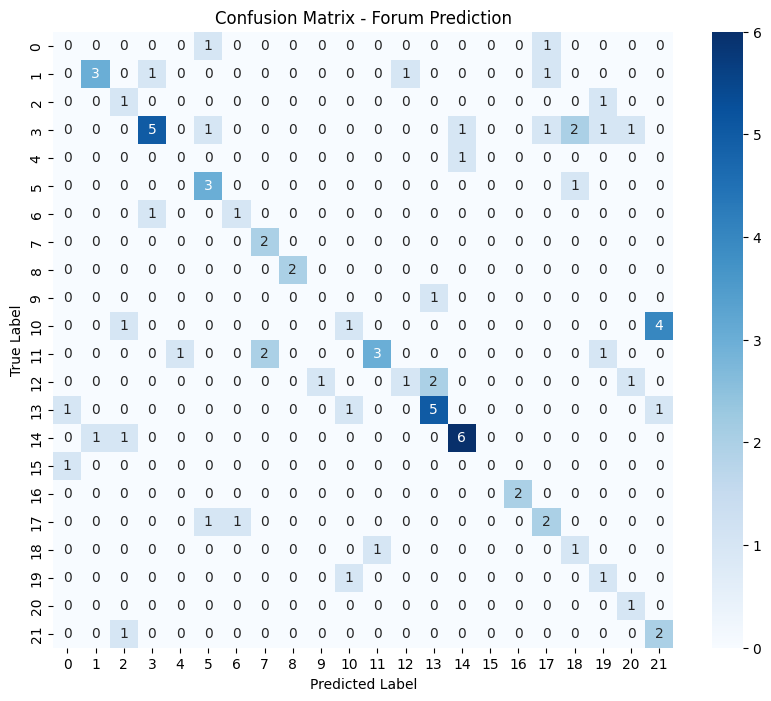

In [26]:
# 4.3 Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Forum Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [27]:
# 4.4 Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Model Accuracy: 50.60%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.75      0.50      0.60         6
           2       0.25      0.50      0.33         2
           3       0.71      0.42      0.53        12
           4       0.00      0.00      0.00         1
           5       0.50      0.75      0.60         4
           6       0.50      0.50      0.50         2
           7       0.50      1.00      0.67         2
           8       1.00      1.00      1.00         2
           9       0.00      0.00      0.00         1
          10       0.33      0.17      0.22         6
          11       0.75      0.43      0.55         7
          12       0.50      0.20      0.29         5
          13       0.62      0.62      0.62         8
          14       0.75      0.75      0.75         8
          15       0.00      0.00      0.00         1
          16       1.00      1.00 

#### Comparision with other models

                                     Model  Accuracy  Weighted F1-Score
              Logistic Regression (TF-IDF)  0.385542           0.370320
                       Linear SVM (TF-IDF)  0.385542           0.396713
          Multinomial Naive Bayes (TF-IDF)  0.289157           0.195582
Logistic Regression (Sentence Transformer)  0.216867           0.217075
         Linear SVM (Sentence Transformer)  0.216867           0.216344


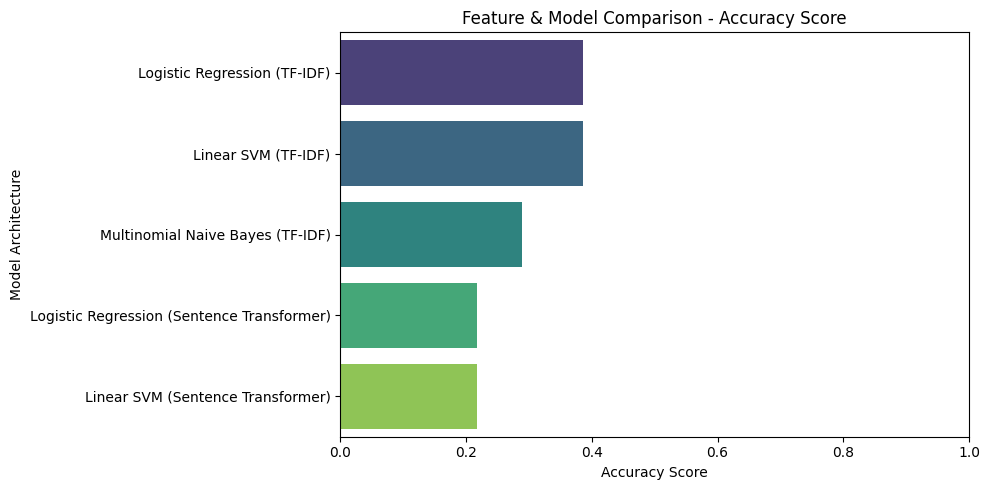

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y_forum_encoded, test_size=0.2, random_state=42
)

X_train_emb, X_test_emb, _, _ = train_test_split(
    X_embeddings, y_forum_encoded, test_size=0.2, random_state=42
)


feature_sets = {
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
    'Sentence Transformer': (X_train_emb, X_test_emb)
}

results = []


for feature_name, (X_tr, X_te) in feature_sets.items():
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        'Linear SVM': SVC(kernel='linear', class_weight='balanced', random_state=42)
    }
    
    
    if feature_name == 'TF-IDF':
        models['Multinomial Naive Bayes'] = MultinomialNB()

    for model_name, model in models.items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        
        acc = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='weighted', zero_division=0
        )
        
        results.append({
            'Feature Engine': feature_name,
            'Model': f"{model_name} ({feature_name})",
            'Accuracy': acc,
            'Weighted Precision': precision,
            'Weighted Recall': recall,
            'Weighted F1-Score': f1
        })


results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(results_df[['Model', 'Accuracy', 'Weighted F1-Score']].to_string(index=False))


plt.figure(figsize=(10, 5))
sns.barplot(
    x='Accuracy', 
    y='Model', 
    data=results_df, 
    palette='viridis', 
    hue='Model', 
    legend=False
)
plt.title('Feature & Model Comparison - Accuracy Score')
plt.xlim(0, 1)
plt.xlabel('Accuracy Score')
plt.ylabel('Model Architecture')
plt.tight_layout()
plt.show()

## 5. Interactive Single-Input Testing

In [29]:
# Create a Dedicated Test Function
def predict_mbti_forum(raw_text, model, vectorizer, encoder):
    """
    Predicts the target forum category for a given raw text input.
    
    Parameters:
    - raw_text (str): Unprocessed text input from user.
    - model: Trained machine learning model (e.g., Linear SVM).
    - vectorizer: Fitted TF-IDF Vectorizer object.
    - encoder: Fitted LabelEncoder object.
    
    Returns:
    - predicted_forum (str): Predicted forum category name.
    """
    # 1. Preprocess raw text using the existing pipeline
    cleaned = clean_text_pipeline(raw_text)
    
    # 2. Transform cleaned text to TF-IDF feature vector
    vectorized = vectorizer.transform([cleaned]).toarray()
    
    # 3. Predict class numeric ID
    pred_numeric = model.predict(vectorized)
    
    # 4. Decode numeric ID back to original forum label
    predicted_forum = encoder.inverse_transform(pred_numeric)[0]
    
    return predicted_forum

In [30]:
# Re-train the Best Model on the Full Dataset
from sklearn.svm import SVC

# Initialize and train the best performing model (Linear SVM with balanced class weights)
final_svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
final_svm_model.fit(X_tfidf, y_forum_encoded)

print("Final model trained successfully on full dataset.")

Final model trained successfully on full dataset.


In [31]:
# Run Interactive Predictions

# Define sample test sentences
sample_input_1 = "I am an INFJ trying to figure out how to handle conflict in my long term relationship."
sample_input_2 = "Which career path offers better work-life balance for an INTJ software engineer?"

# Perform single-input predictions
result_1 = predict_mbti_forum(sample_input_1, final_svm_model, tfidf_vectorizer, label_encoder)
result_2 = predict_mbti_forum(sample_input_2, final_svm_model, tfidf_vectorizer, label_encoder)

# Display results
print(f"Input 1: '{sample_input_1}'")
print(f"Predicted Forum: {result_1}\n")

print(f"Input 2: '{sample_input_2}'")
print(f"Predicted Forum: {result_2}")

Input 1: 'I am an INFJ trying to figure out how to handle conflict in my long term relationship.'
Predicted Forum: INFJ - Counselor

Input 2: 'Which career path offers better work-life balance for an INTJ software engineer?'
Predicted Forum: INTJ - Mastermind


In [32]:
# Interactive Input Widget
import ipywidgets as widgets
from IPython.display import display

# Create interactive UI components
text_input = widgets.Textarea(
    value='How do ENFPs perform under high pressure work environments?',
    placeholder='Type your MBTI post here...',
    description='Text:',
    disabled=False,
    layout=widgets.Layout(width='80%', height='100px')
)

button = widgets.Button(description="Predict Forum")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        prediction = predict_mbti_forum(text_input.value, final_svm_model, tfidf_vectorizer, label_encoder)
        print(f"Predicted Category: {prediction}")

button.on_click(on_button_clicked)

display(text_input, button, output)

Textarea(value='How do ENFPs perform under high pressure work environments?', description='Text:', layout=Layo…

Button(description='Predict Forum', style=ButtonStyle())

Output()